In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv("HealthyCity_NGO_Dataset.csv")

In [3]:
df.head()

,patient_id,age,sex,region,smoker,bmi,chronic_conditions,visits_last_year,bp_sys,bp_dia,cholesterol_mg_dl,glucose_mg_dl,vaccinated_flu,hospitalized,disease_severity
0,HC00001,54,Female,South,No,28.4,0,1,137,82,183,119,Yes,0,Mild
1,HC00002,30,Female,South,No,17.2,2,4,145,72,191,115,No,0,Moderate
2,HC00003,63,Male,South,Yes,35.0,4,5,167,87,224,126,Yes,1,Moderate
3,HC00004,66,Female,South,Yes,31.8,3,4,164,99,210,118,Yes,0,Moderate
4,HC00005,18,Female,West,No,30.0,0,2,127,71,152,90,No,0,Mild


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   patient_id          2000 non-null   object 
 1   age                 2000 non-null   int64  
 2   sex                 2000 non-null   object 
 3   region              2000 non-null   object 
 4   smoker              2000 non-null   object 
 5   bmi                 2000 non-null   float64
 6   chronic_conditions  2000 non-null   int64  
 7   visits_last_year    2000 non-null   int64  
 8   bp_sys              2000 non-null   int64  
 9   bp_dia              2000 non-null   int64  
 10  cholesterol_mg_dl   2000 non-null   int64  
 11  glucose_mg_dl       2000 non-null   int64  
 12  vaccinated_flu      2000 non-null   object 
 13  hospitalized        2000 non-null   int64  
 14  disease_severity    2000 non-null   object 
dtypes: float64(1), int64(8), object(6)
memory usage: 234.5+

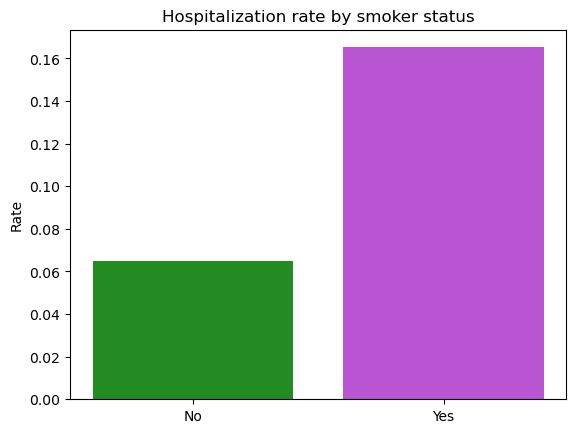

In [5]:
# Compare hospitalization rate for smokers vs non-smokers

smoker_rates = df.groupby('smoker')['hospitalized'].mean()

plt.bar(smoker_rates.index, smoker_rates.values, color=['forestgreen', 'mediumorchid'])
plt.title("Hospitalization rate by smoker status")
plt.ylabel("Rate")
plt.show()

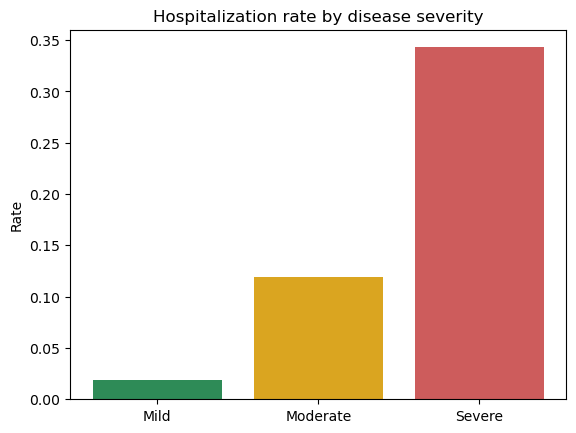

In [6]:
# Compare hospitalization rate for mild, moderate and severe diseases

disease_rates = df.groupby('disease_severity')['hospitalized'].mean()

plt.bar(disease_rates.index, disease_rates.values, color=['seagreen', 'goldenrod', 'indianred'])
plt.title("Hospitalization rate by disease severity")
plt.ylabel("Rate")
plt.show()

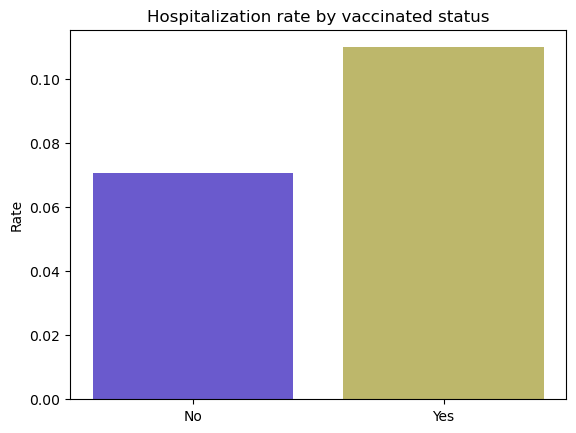

In [7]:
# Compare hospitalization rate for those vaccinated and not vaccinated

vaccinated_rates = df.groupby('vaccinated_flu')['hospitalized'].mean()

plt.bar(vaccinated_rates.index, vaccinated_rates.values, color=['slateblue', 'darkkhaki'])
plt.title("Hospitalization rate by vaccinated status")
plt.ylabel("Rate")
plt.show()

In [8]:
df["hospitalized"] = df["hospitalized"].map({0: "Not Hospitalized", 1: "Hospitalized"})

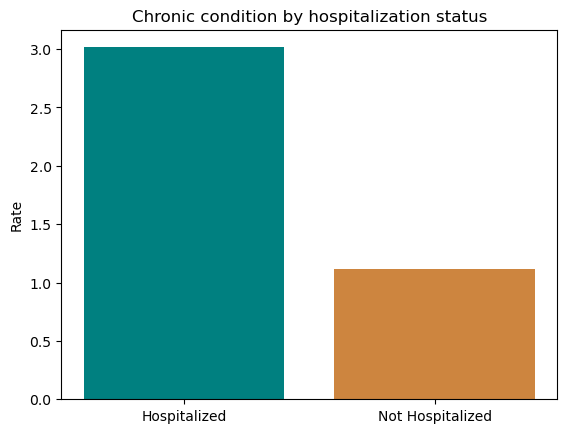

In [9]:
# Compare chronic condition rate to hospitalization status

condition_rates = df.groupby('hospitalized')['chronic_conditions'].mean()

plt.bar(condition_rates.index, condition_rates.values, color=['teal', 'peru'])
plt.title("Chronic condition by hospitalization status")
plt.ylabel("Rate")
plt.show()

In [10]:
cat = LabelEncoder()
df['smoker'] = cat.fit_transform(df['smoker'])
df['vaccinated_flu'] = cat.fit_transform(df['vaccinated_flu'])
df['disease_severity'] = cat.fit_transform(df['disease_severity'])
df['hospitalized'] = df['hospitalized'].map({"Not Hospitalized": 0, "Hospitalized": 1}).astype(int)

In [11]:
# Selected columns
cols_to_corr = ['chronic_conditions', 'disease_severity', 'vaccinated_flu', 'glucose_mg_dl',
                'hospitalized']

# Subset dataframe
subset_df = df[cols_to_corr]

# Compute correlation
corr_matrix = subset_df.corr()

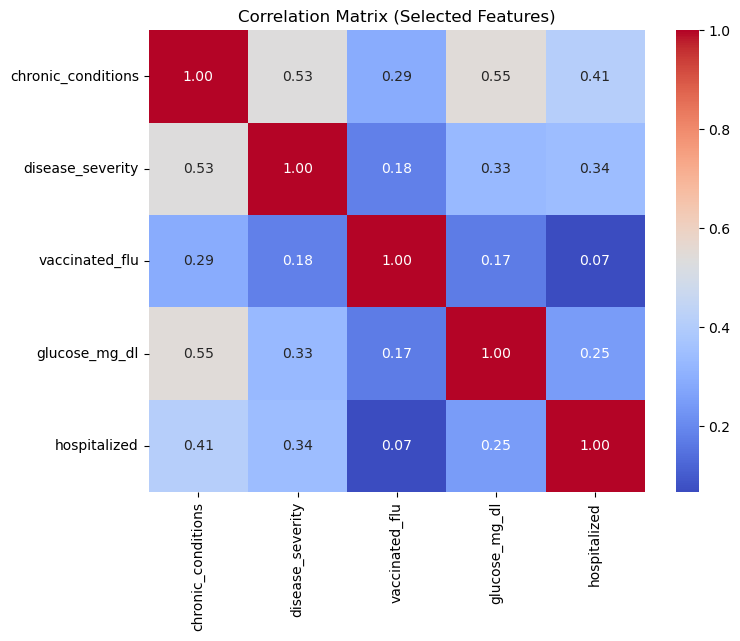

In [12]:
# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix (Selected Features)")
plt.show()